In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
delta_t = reader.fetch_data_from_h5("/home/thur0011/GYSELA/simulations_raw/fresh_batch_8.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "/home/thur0011/GYSELA/simulations_raw/fresh_batch_8.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5/sp0/Phi2D");

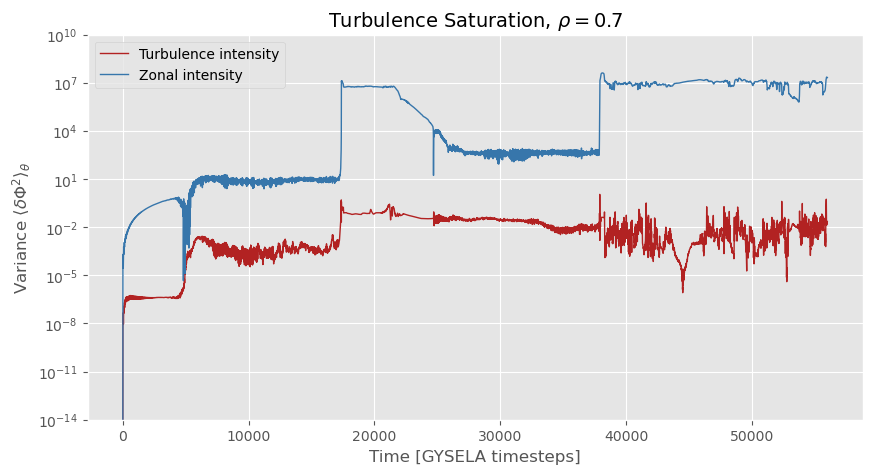

In [ ]:
def generate_turbulent_variance_time_series(phi2D_list, effective_radius = None):

	# Cull zonal component to extract turbulence intensity.
	operation = lambda entry: (entry ** 2).mean(dim = "theta") - (entry.mean(dim = "theta")) ** 2;
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	variance_series = xr.concat(radial_strips, dim = "time");

	if not effective_radius is None:
		variance_series = utils.slice_at_effective_radius(variance_series, effective_radius);

	return variance_series;

def generate_zonal_time_series(phi2D_list, effective_radius = None):

	# Take a simple poloidal average and square to isolate zonal mode intensities.
	operation = lambda entry: entry.mean(dim = "theta") ** 2;
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	zonal_series = xr.concat(radial_strips, dim = "time");

	if not effective_radius is None:
		zonal_series = utils.slice_at_effective_radius(zonal_series, effective_radius);

	return zonal_series;

def plot_turbulence_saturation(phi2D_list, delta_t, dt_diag, effective_radius, log_scale = False):

	variance_series = generate_turbulent_variance_time_series(phi2D_list, effective_radius);
	zonal_series = generate_zonal_time_series(phi2D_list, effective_radius);
	stride = utils.calculate_stride(delta_t, dt_diag);
	time_range = np.arange(len(variance_series)) * stride;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	operation = plt.semilogy if log_scale else plt.plot;
	operation(time_range, variance_series, color = "firebrick", lw = 1.0, label = "Turbulence intensity");
	operation(time_range, zonal_series, color = "#3776ab", lw = 1.0, label = "Zonal intensity");
	plt.title(f"Turbulence Saturation, $\\rho = {effective_radius}$", fontsize = 14);
	plt.xlabel("Time [GYSELA timesteps]", fontsize = 12);
	plt.ylabel(r"Variance $\langle \delta \Phi^2 \rangle_\theta$", fontsize = 12);
	plt.ylim(10e-15, 10e9);
	plt.legend();
	plt.show();

plot_turbulence_saturation(data_arrays, delta_t, dt_diag = 125, effective_radius = 0.7, log_scale = True);